In [1]:
import numpy as np
import gzip
import struct
import os
import matplotlib.pyplot as plt
import time
from tqdm import tqdm  
import pickle

In [2]:
from neural_network import *
from models import MLP, CNN, ResNet

In [3]:
np.random.seed(42)

In [4]:
os.makedirs('./saved_models', exist_ok=True)
os.makedirs('./figs', exist_ok=True)

In [5]:
print("Loading MNIST dataset...")
# 数据集路径
train_images_path = './dataset/MNIST/train-images-idx3-ubyte.gz'
train_labels_path = './dataset/MNIST/train-labels-idx1-ubyte.gz'
test_images_path = './dataset/MNIST/t10k-images-idx3-ubyte.gz'
test_labels_path = './dataset/MNIST/t10k-labels-idx1-ubyte.gz'

Loading MNIST dataset...


In [6]:
# 加载训练图像
with gzip.open(train_images_path, 'rb') as f:
    magic, num, rows, cols = struct.unpack('>4I', f.read(16))
    train_images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)

In [7]:
# 加载训练标签
with gzip.open(train_labels_path, 'rb') as f:
    magic, num = struct.unpack('>2I', f.read(8))
    train_labels = np.frombuffer(f.read(), dtype=np.uint8)

In [8]:
# 测试图像
with gzip.open(test_images_path, 'rb') as f:
    magic, num, rows, cols = struct.unpack('>4I', f.read(16))
    test_images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)

In [9]:
# 测试标签
with gzip.open(test_labels_path, 'rb') as f:
    magic, num = struct.unpack('>2I', f.read(8))
    test_labels = np.frombuffer(f.read(), dtype=np.uint8)

In [10]:
# 归一化图像数据到[0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

In [11]:
# reshape图像数据为卷积格式[N, C, H, W]
train_images_conv = train_images.reshape(-1, 1, 28, 28)
test_images_conv = test_images.reshape(-1, 1, 28, 28)

In [12]:
# 分割验证集
print("Splitting validation set...")

val_ratio = 0.1
num_samples = train_images.shape[0]
indices = np.random.permutation(num_samples)
val_size = int(num_samples * val_ratio)

Splitting validation set...


In [13]:
val_indices = indices[:val_size]
train_indices = indices[val_size:]

In [14]:
X_train_flat, y_train = train_images[train_indices], train_labels[train_indices]
X_val_flat, y_val = train_images[val_indices], train_labels[val_indices]
X_train_conv, y_train_conv = train_images_conv[train_indices], train_labels[train_indices]
X_val_conv, y_val_conv = train_images_conv[val_indices], train_labels[val_indices]

In [15]:
# 训练批次生成
def get_batch(X, y, batch_size):
    num_samples = X.shape[0]
    indices = np.random.permutation(num_samples)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

In [16]:
# 数据增强函数
def augment_data(X, y, augment_factor=2):
    N, C, H, W = X.shape
    X_aug = [X]
    y_aug = [y]
    
    for _ in range(augment_factor - 1):
        # 随机平移
        shifted = np.zeros_like(X)
        for i in range(N):
            dx, dy = np.random.randint(-3, 4, 2)
            for c in range(C):
                for h in range(H):
                    for w in range(W):
                        h_new, w_new = h + dy, w + dx
                        if 0 <= h_new < H and 0 <= w_new < W:
                            shifted[i, c, h, w] = X[i, c, h_new, w_new]
        
        X_aug.append(shifted)
        y_aug.append(y)

    X_aug_combined = np.concatenate(X_aug, axis=0)
    y_aug_combined = np.concatenate(y_aug, axis=0)
    
    return X_aug_combined, y_aug_combined

In [17]:
# 可视化权重函数
def visualize_weights(model, layer_index=0, save_path=None):
    # 获取卷积层
    conv_layers = [i for i, layer in enumerate(model.layers) if isinstance(layer, Conv2D)]
    
    if not conv_layers:
        print("No convolutional layers in model")
        return
    
    if layer_index >= len(conv_layers):
        layer_index = conv_layers[0]
    else:
        layer_index = conv_layers[layer_index]
    
    layer = model.layers[layer_index]
    weights = layer.W
    
    # 获取权重
    n_filters, n_channels, h, w = weights.shape
    
    # 计算显示的网格大小
    grid_size = int(np.ceil(np.sqrt(n_filters)))
    
    # 图形
    plt.figure(figsize=(12, 12))
    
    for i in range(n_filters):
        if i >= grid_size * grid_size:
            break
            
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(weights[i, 0], cmap='viridis')
        plt.axis('off')
    
    plt.suptitle(f'Convolutional Layer Filters Visualization (Layer {layer_index})', fontsize=16)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()

In [18]:
# 模型评估
def evaluate_model(model, X, y, batch_size=128):
    model.set_train(False)
    total_loss = 0
    correct = 0
    samples = 0
    
    for X_batch, y_batch in get_batch(X, y, batch_size):
        # 前向传播
        y_pred = model(X_batch)
        
        loss_fn = CrossEntropyLoss()
        loss = loss_fn.forward(y_pred, y_batch)
        total_loss += loss * X_batch.shape[0]
        
        # 计算准确率
        pred = np.argmax(y_pred, axis=1)
        correct += np.sum(pred == y_batch)
        samples += X_batch.shape[0]
    
    avg_loss = total_loss / samples
    accuracy = correct / samples
    
    model.set_train(True)
    return accuracy, avg_loss

In [19]:
def save_history(history, filename):
    with open(filename, 'wb') as f:
        pickle.dump(history, f)

In [20]:
def load_history(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

In [21]:
# 训练历史
def plot_history(history, title="Model Training History", save_path=None):
    plt.figure(figsize=(12, 4))
    
    # 绘失
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss Evolution')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # 准确率
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy Evolution')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()

In [22]:
def plot_model_comparison(histories, model_names, metric='val_acc', title="Model Comparison", save_path=None):
    plt.figure(figsize=(10, 6))
    
    for i, history in enumerate(histories):
        plt.plot(history[metric], label=model_names[i])
    
    if metric == 'val_acc':
        plt.title('Validation Accuracy Comparison')
        plt.ylabel('Accuracy')
    elif metric == 'val_loss':
        plt.title('Validation Loss Comparison')
        plt.ylabel('Loss')
    
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.suptitle(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()

In [23]:
# --------------------- 开始实验 ---------------------
print("Starting experiments...")

Starting experiments...


In [24]:
# 模型参数
batch_size = 128
epochs = 10

In [25]:
# 开始时间
start_time = time.time()

In [26]:
# --------------------- 基础MLP模型 ---------------------
print("\n[Experiment 1] Training basic MLP model...")
mlp_model = MLP(input_dim=784, hidden_dims=[128], num_classes=10, use_dropout=False)
mlp_optimizer = SGD(mlp_model, learning_rate=0.01)


[Experiment 1] Training basic MLP model...


In [27]:
mlp_history = {
    'train_loss': [], 'train_acc': [], 
    'val_loss': [], 'val_acc': [],
    'best_val_acc': 0
}

In [28]:
for epoch in range(epochs):
    mlp_model.set_train(True)
    train_loss = 0
    train_correct = 0
    train_samples = 0
    
    # 训练一个epoch
    for X_batch, y_batch in tqdm(get_batch(X_train_flat, y_train, batch_size), 
                                desc=f"Epoch {epoch+1}/{epochs}", 
                                total=len(X_train_flat)//batch_size):
        # 前向传播
        y_pred = mlp_model(X_batch)
        
        # 计算损失 - 直接调用forward方法而不是使用__call__
        loss_fn = CrossEntropyLoss(mlp_model)
        loss = loss_fn.forward(y_pred, y_batch)
        
        # 反向传播
        loss_fn.backward()
        
        # 参数更新
        mlp_optimizer.step()
        
        # 统计
        pred = np.argmax(y_pred, axis=1)
        train_correct += np.sum(pred == y_batch)
        train_loss += loss * X_batch.shape[0]
        train_samples += X_batch.shape[0]
    
    avg_train_loss = train_loss / train_samples
    train_accuracy = train_correct / train_samples
    
    # 验证集评估
    val_accuracy, avg_val_loss = evaluate_model(mlp_model, X_val_flat, y_val, batch_size)
    
    mlp_history['train_loss'].append(avg_train_loss)
    mlp_history['train_acc'].append(train_accuracy)
    mlp_history['val_loss'].append(avg_val_loss)
    mlp_history['val_acc'].append(val_accuracy)
    
    if val_accuracy > mlp_history['best_val_acc']:
        mlp_history['best_val_acc'] = val_accuracy
        mlp_model.save('./saved_models/best_mlp_model.pkl')
    
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

Epoch 1/10: 422it [00:01, 418.33it/s]                         


Epoch 1/10, Train Loss: 1.2698, Train Acc: 0.7033, Val Loss: 0.7318, Val Acc: 0.8402


Epoch 2/10: 422it [00:00, 448.22it/s]                         


Epoch 2/10, Train Loss: 0.5945, Train Acc: 0.8595, Val Loss: 0.5080, Val Acc: 0.8745


Epoch 3/10: 422it [00:01, 376.01it/s]                         


...

Epoch 8/10, Train Loss: 0.3213, Train Acc: 0.9105, Val Loss: 0.3103, Val Acc: 0.9160


Epoch 9/10: 422it [00:01, 389.26it/s]                         


Epoch 9/10, Train Loss: 0.3098, Train Acc: 0.9134, Val Loss: 0.3002, Val Acc: 0.9188


Epoch 10/10: 422it [00:00, 439.87it/s]                         


Epoch 10/10, Train Loss: 0.2999, Train Acc: 0.9161, Val Loss: 0.2905, Val Acc: 0.9217


In [29]:
# 保存最终模型和训练历史
mlp_model.save('./saved_models/final_mlp_model.pkl')
save_history(mlp_history, './saved_models/mlp_history.pkl')

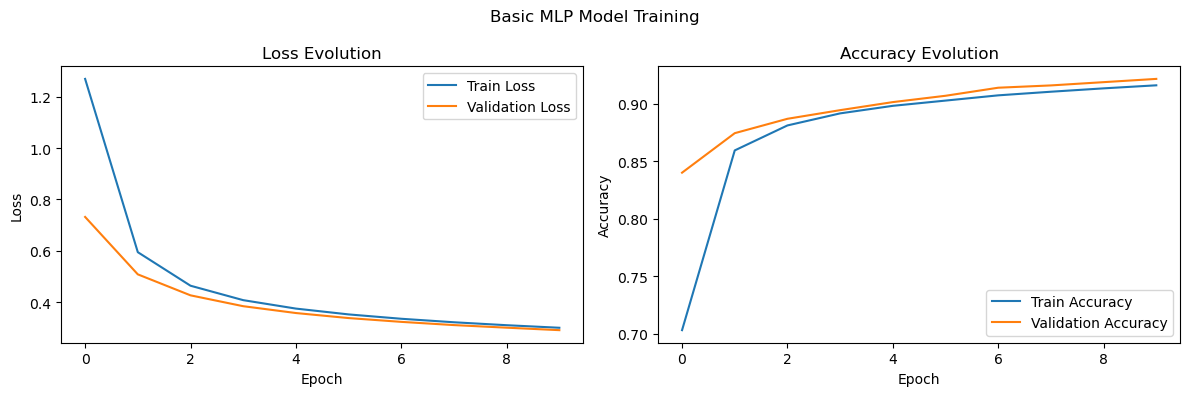

In [30]:
plot_history(mlp_history, title="Basic MLP Model Training", save_path="./figs/mlp_training.png")

In [31]:
# --------------------- 改进的MLP模型 ---------------------
print("\n[Experiment 2] Training improved MLP model...")
improved_mlp_model = MLP(input_dim=784, hidden_dims=[256, 128], num_classes=10, use_dropout=True)
improved_mlp_optimizer = Adam(improved_mlp_model, learning_rate=0.001)


[Experiment 2] Training improved MLP model...


In [32]:
improved_mlp_history = {
    'train_loss': [], 'train_acc': [], 
    'val_loss': [], 'val_acc': [],
    'best_val_acc': 0
}

In [33]:
for epoch in range(epochs):
    improved_mlp_model.set_train(True)
    train_loss = 0
    train_correct = 0
    train_samples = 0
    
    # 训练一个epoch
    for X_batch, y_batch in tqdm(get_batch(X_train_flat, y_train, batch_size), 
                                desc=f"Epoch {epoch+1}/{epochs}", 
                                total=len(X_train_flat)//batch_size):
        # 前向传播
        y_pred = improved_mlp_model(X_batch)
        
        loss_fn = CrossEntropyLoss(improved_mlp_model)
        loss = loss_fn.forward(y_pred, y_batch)
        
        # 反向传播
        loss_fn.backward()
        
        # 参数更新
        improved_mlp_optimizer.step()
        
        # 统计
        pred = np.argmax(y_pred, axis=1)
        train_correct += np.sum(pred == y_batch)
        train_loss += loss * X_batch.shape[0]
        train_samples += X_batch.shape[0]
    
    # 计算训练集指标
    avg_train_loss = train_loss / train_samples
    train_accuracy = train_correct / train_samples
    
    # 验证集评估
    val_accuracy, avg_val_loss = evaluate_model(improved_mlp_model, X_val_flat, y_val, batch_size)
    
    improved_mlp_history['train_loss'].append(avg_train_loss)
    improved_mlp_history['train_acc'].append(train_accuracy)
    improved_mlp_history['val_loss'].append(avg_val_loss)
    improved_mlp_history['val_acc'].append(val_accuracy)
    
    if val_accuracy > improved_mlp_history['best_val_acc']:
        improved_mlp_history['best_val_acc'] = val_accuracy
        improved_mlp_model.save('./saved_models/best_improved_mlp_model.pkl')
    
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

Epoch 1/10: 422it [00:04, 97.71it/s]                          


Epoch 1/10, Train Loss: 0.5642, Train Acc: 0.8271, Val Loss: 0.1781, Val Acc: 0.9470


Epoch 2/10: 422it [00:04, 102.53it/s]                         


Epoch 2/10, Train Loss: 0.2607, Train Acc: 0.9256, Val Loss: 0.1287, Val Acc: 0.9608


Epoch 3/10: 422it [00:04, 99.52it/s]                          


...

Epoch 8/10, Train Loss: 0.1235, Train Acc: 0.9633, Val Loss: 0.0754, Val Acc: 0.9753


Epoch 9/10: 422it [00:04, 103.22it/s]                         


Epoch 9/10, Train Loss: 0.1153, Train Acc: 0.9659, Val Loss: 0.0712, Val Acc: 0.9797


Epoch 10/10: 422it [00:04, 101.98it/s]                         

Epoch 10/10, Train Loss: 0.1116, Train Acc: 0.9671, Val Loss: 0.0674, Val Acc: 0.9790


In [34]:
# 保存最终模型和训练历史
improved_mlp_model.save('./saved_models/final_improved_mlp_model.pkl')
save_history(improved_mlp_history, './saved_models/improved_mlp_history.pkl')

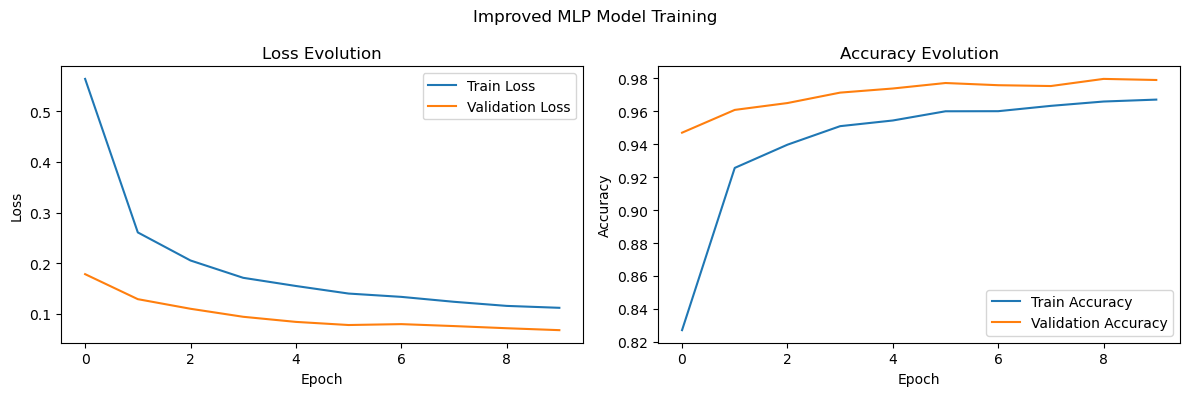

In [35]:
# 绘制训练历史
plot_history(improved_mlp_history, title="Improved MLP Model Training", save_path="./figs/improved_mlp_training.png")

In [36]:
# --------------------- CNN模型 ---------------------
print("\n[Experiment 3] Training CNN model...")


print(f"使用原始训练集，大小: {X_train_conv.shape[0]}")

# CNN模型参数调整
cnn_batch_size = 256  # 增大批次大小
cnn_epochs = 10  # 恢复为10个训练轮次


[Experiment 3] Training CNN model...
使用原始训练集，大小: 54000


In [37]:

cnn_model = CNN(input_shape=(1, 28, 28), num_classes=10)
cnn_optimizer = Adam(cnn_model, learning_rate=0.005)

In [38]:
# 记录训练历史
cnn_history = {
    'train_loss': [], 'train_acc': [], 
    'val_loss': [], 'val_acc': [],
    'best_val_acc': 0
}

In [39]:
# 训练CNN模型
for epoch in range(cnn_epochs): 
    cnn_model.set_train(True)
    train_loss = 0
    train_correct = 0
    train_samples = 0
    
    # 训练一个epoch
    for X_batch, y_batch in tqdm(get_batch(X_train_conv, y_train, cnn_batch_size),
                                desc=f"Epoch {epoch+1}/{cnn_epochs}", 
                                total=len(X_train_conv)//cnn_batch_size):
        # 前向传播
        y_pred = cnn_model(X_batch)
        
        loss_fn = CrossEntropyLoss(cnn_model)
        loss = loss_fn.forward(y_pred, y_batch)
        
        # 反向传播
        loss_fn.backward()
        
        # 参数更新
        cnn_optimizer.step()
        
        # 统计
        pred = np.argmax(y_pred, axis=1)
        train_correct += np.sum(pred == y_batch)
        train_loss += loss * X_batch.shape[0]
        train_samples += X_batch.shape[0]
    
    # 计算训练集指标
    avg_train_loss = train_loss / train_samples
    train_accuracy = train_correct / train_samples
    
    # 验证集评估
    val_accuracy, avg_val_loss = evaluate_model(cnn_model, X_val_conv, y_val, cnn_batch_size)
    
    # 保存指标
    cnn_history['train_loss'].append(avg_train_loss)
    cnn_history['train_acc'].append(train_accuracy)
    cnn_history['val_loss'].append(avg_val_loss)
    cnn_history['val_acc'].append(val_accuracy)
    
    if val_accuracy > cnn_history['best_val_acc']:
        cnn_history['best_val_acc'] = val_accuracy
        cnn_model.save('./saved_models/best_cnn_model.pkl')
    
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

Epoch 1/10: 211it [00:12, 17.23it/s]                         


Epoch 1/10, Train Loss: 0.3609, Train Acc: 0.8925, Val Loss: 0.1316, Val Acc: 0.9655


Epoch 2/10: 211it [00:13, 15.45it/s]                         


Epoch 2/10, Train Loss: 0.1151, Train Acc: 0.9660, Val Loss: 0.0992, Val Acc: 0.9732


Epoch 3/10: 211it [00:12, 16.76it/s]                         


...

Epoch 8/10, Train Loss: 0.0395, Train Acc: 0.9875, Val Loss: 0.0617, Val Acc: 0.9835


Epoch 9/10: 211it [00:13, 16.23it/s]                         


Epoch 9/10, Train Loss: 0.0355, Train Acc: 0.9884, Val Loss: 0.0668, Val Acc: 0.9835


Epoch 10/10: 211it [00:13, 16.21it/s]                         


Epoch 10/10, Train Loss: 0.0325, Train Acc: 0.9892, Val Loss: 0.0683, Val Acc: 0.9825


In [40]:
cnn_model.save('./saved_models/final_cnn_model.pkl')
save_history(cnn_history, './saved_models/cnn_history.pkl')

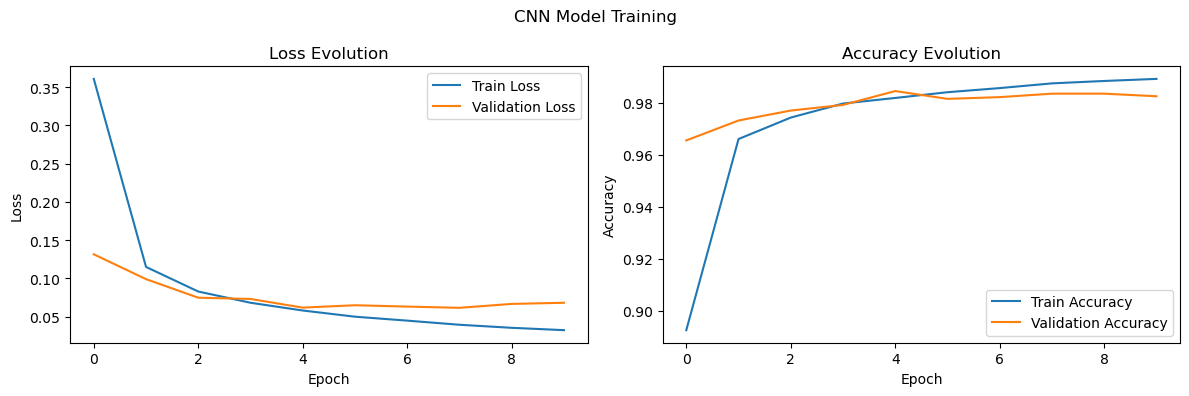

In [41]:
plot_history(cnn_history, title="CNN Model Training", save_path="./figs/cnn_training.png")

In [42]:
# --------------------- 模型权重可视化 ---------------------
print("\n[Visualization] Visualizing CNN filters...")


[Visualization] Visualizing CNN filters...


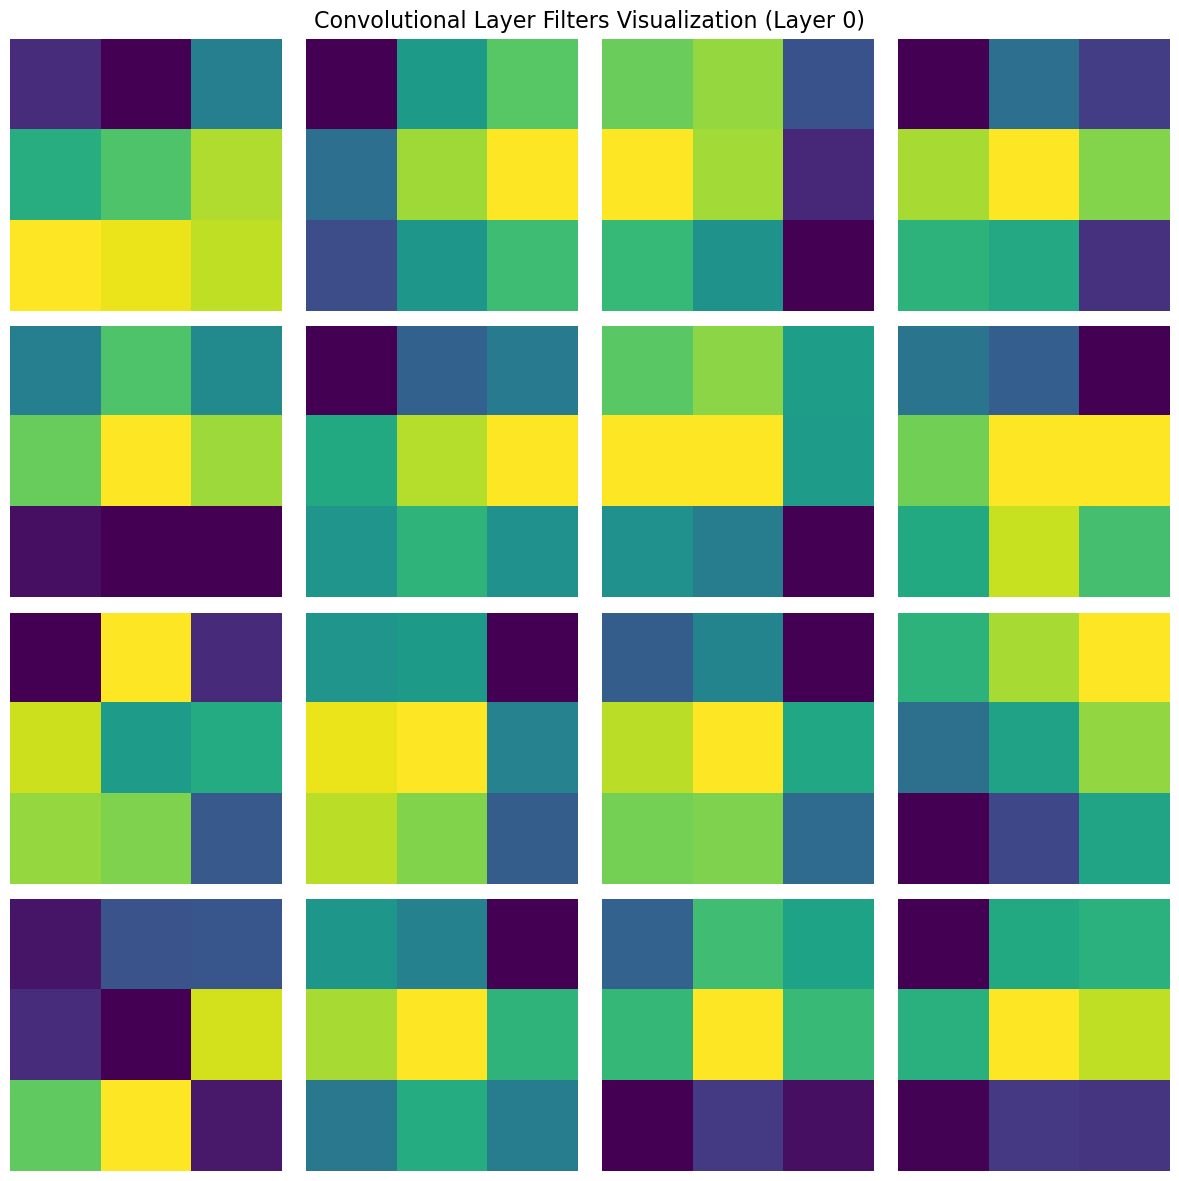

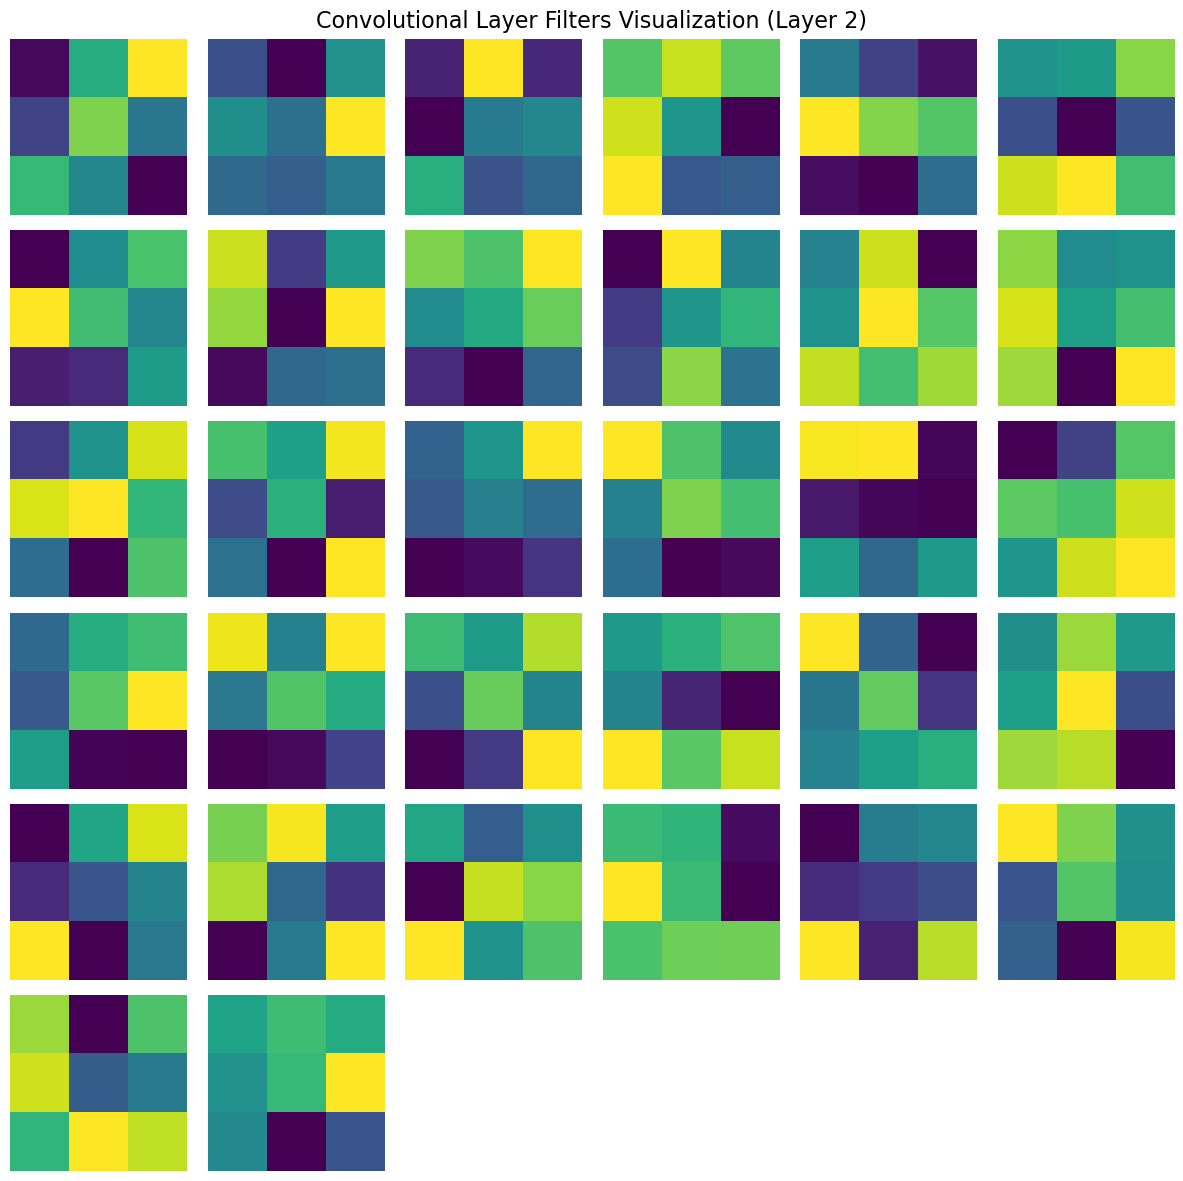

In [43]:
# 可视化卷积层权重
visualize_weights(cnn_model, layer_index=0, save_path="./figs/cnn_filters_layer1.png")
if len([i for i, layer in enumerate(cnn_model.layers) if isinstance(layer, Conv2D)]) > 1:
    visualize_weights(cnn_model, layer_index=1, save_path="./figs/cnn_filters_layer2.png")


[Comparison] Comparing all models...


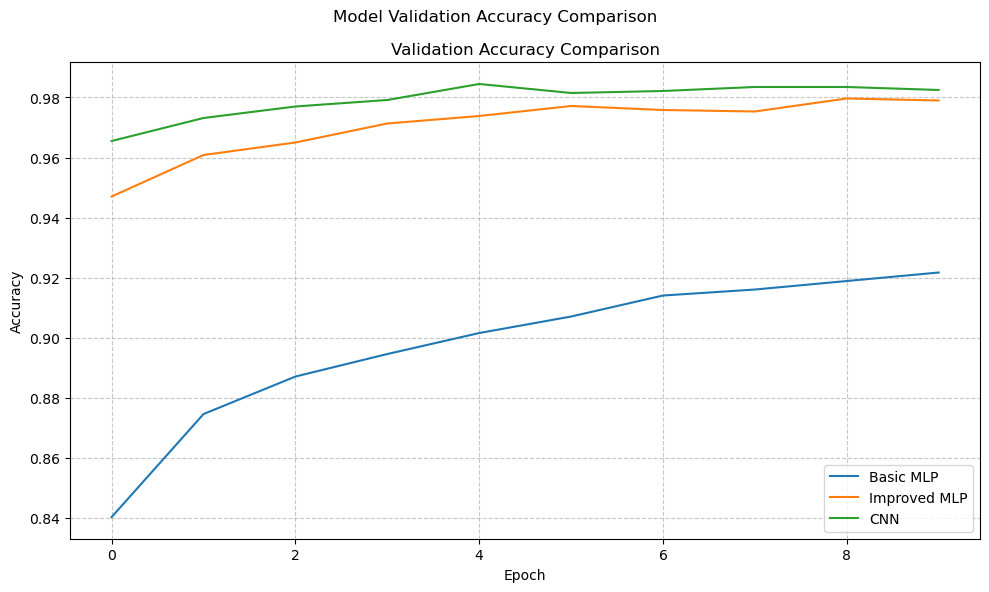

In [44]:
# --------------------- 模型比较 ---------------------
print("\n[Comparison] Comparing all models...")
# 比较所有模型在验证集上的性能
plot_model_comparison(
    [mlp_history, improved_mlp_history, cnn_history],
    ['Basic MLP', 'Improved MLP', 'CNN'],
    metric='val_acc',
    title="Model Validation Accuracy Comparison",
    save_path="./figs/model_comparison_acc.png"
)

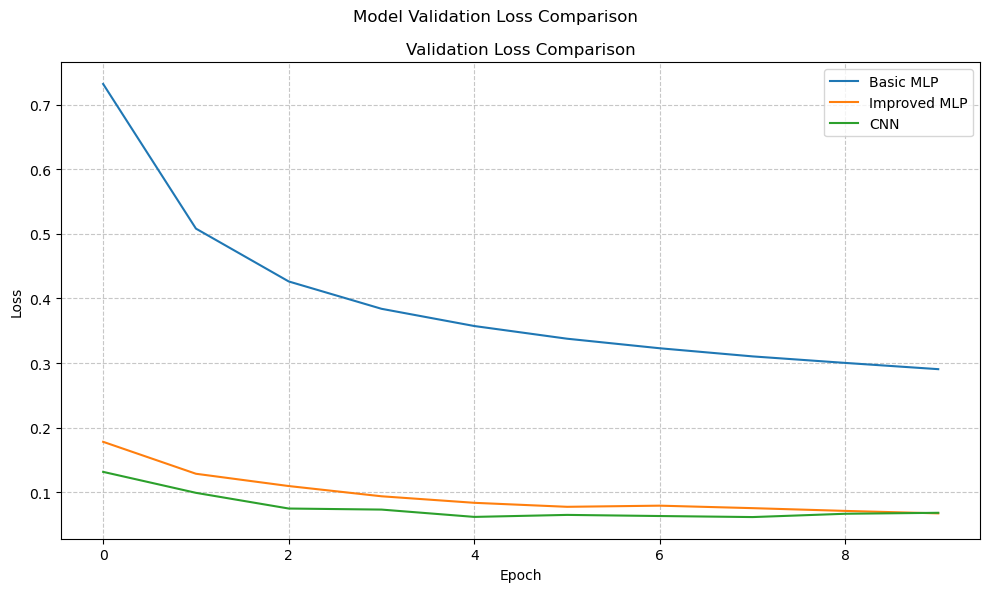

In [45]:
plot_model_comparison(
    [mlp_history, improved_mlp_history, cnn_history],
    ['Basic MLP', 'Improved MLP', 'CNN'],
    metric='val_loss',
    title="Model Validation Loss Comparison",
    save_path="./figs/model_comparison_loss.png"
)

In [46]:
# --------------------- 在测试集上评估所有模型 ---------------------
print("\n[Evaluation] Evaluating all models on test set...")
# 使用当前训练好的模型，不加载保存的模型文件
# best_mlp_model = MLP(input_dim=784, hidden_dims=[128], num_classes=10)
# best_mlp_model.load('./saved_models/best_mlp_model.pkl')


[Evaluation] Evaluating all models on test set...


In [47]:
# best_improved_mlp_model = MLP(input_dim=784, hidden_dims=[256, 128], num_classes=10)
# best_improved_mlp_model.load('./saved_models/best_improved_mlp_model.pkl')

In [48]:
# 使用当前训练好的CNN模型
# best_cnn_model = CNN(input_shape=(1, 28, 28), num_classes=10)
# best_cnn_model.load('./saved_models/best_cnn_model.pkl')

In [49]:
mlp_test_acc, mlp_test_loss = evaluate_model(mlp_model, test_images, test_labels)
improved_mlp_test_acc, improved_mlp_test_loss = evaluate_model(improved_mlp_model, test_images, test_labels)
cnn_test_acc, cnn_test_loss = evaluate_model(cnn_model, test_images_conv, test_labels)

In [50]:
print("\nTest Set Results:")
print(f"Basic MLP - Accuracy: {mlp_test_acc:.4f}, Loss: {mlp_test_loss:.4f}")
print(f"Improved MLP - Accuracy: {improved_mlp_test_acc:.4f}, Loss: {improved_mlp_test_loss:.4f}")
print(f"CNN - Accuracy: {cnn_test_acc:.4f}, Loss: {cnn_test_loss:.4f}")


Test Set Results:
Basic MLP - Accuracy: 0.9213, Loss: 0.2822
Improved MLP - Accuracy: 0.9791, Loss: 0.0735
CNN - Accuracy: 0.9826, Loss: 0.0589


In [51]:
models = ['Basic MLP', 'Improved MLP', 'CNN']
test_accuracies = [mlp_test_acc, improved_mlp_test_acc, cnn_test_acc]
test_losses = [mlp_test_loss, improved_mlp_test_loss, cnn_test_loss]

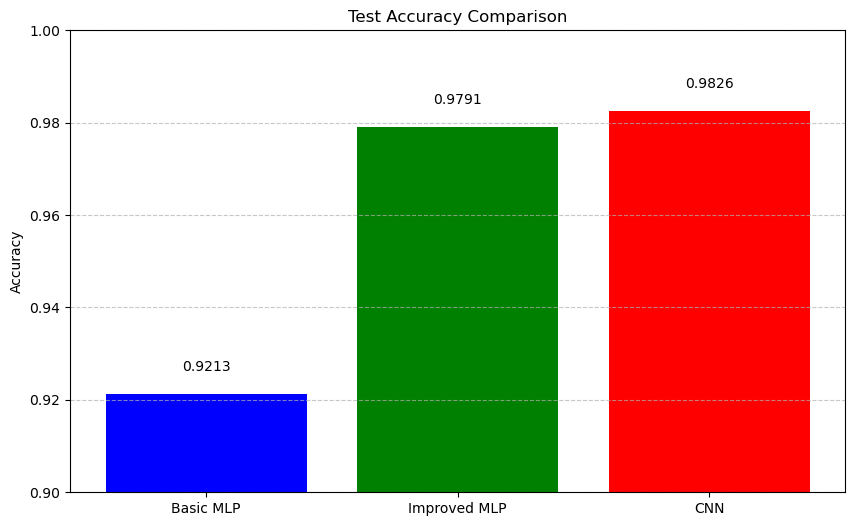

In [52]:
# 准确率对比
plt.figure(figsize=(10, 6))
plt.bar(models, test_accuracies, color=['blue', 'green', 'red'])
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(test_accuracies):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')
plt.savefig('./figs/test_accuracy_comparison.png')
plt.show()

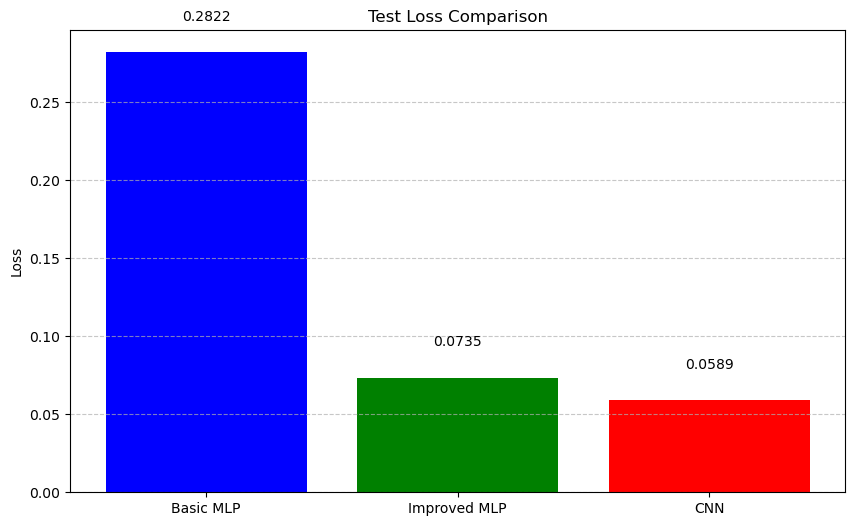

In [53]:
# 损失对比
plt.figure(figsize=(10, 6))
plt.bar(models, test_losses, color=['blue', 'green', 'red'])
plt.title('Test Loss Comparison')
plt.ylabel('Loss')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(test_losses):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.savefig('./figs/test_loss_comparison.png')
plt.show()